# Phenotype Prediction

### Imports

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import (
    RandomForestClassifier,
    StackingClassifier,
    VotingClassifier,
)
from sklearn.feature_selection import SelectKBest, VarianceThreshold, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_val_predict,
    cross_val_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

sys.path.insert(0, str(Path.cwd().parent))
sys.path.insert(0, str(Path.cwd().parent / "benchmark"))
from maskel.config import ExtractionConfig, OutputConfig, PipelineConfig
from maskel.pipeline import analyze_segmentation_mask

from hrf import HRFDataset, preprocess_segmentation

In [2]:
# Init HRF dataset
dataset = HRFDataset("../data/HRF")

# Config with ALL features and cleanup enabled
config = PipelineConfig(
    extraction=ExtractionConfig(
        branches=True,
        nodes=True,
        summary=True,
        fractal_dimension=True,
        mask_radius=True,
        junction_cleanup=True,
        cleanup_threshold_factor=2.5,
        closing_iterations=0,
        fill_holes=True,
        max_hole_size=300,
    ),
    output=OutputConfig(),
)

# Process all 45 HRF samples through maskel with full feature extraction
results = []
for i in range(len(dataset)):
    print(f"Processing sample {i + 1}/{len(dataset)}")
    _, seg, mask, info = dataset.load_sample(i)
    binary = preprocess_segmentation(seg, mask, min_size=50)
    result = analyze_segmentation_mask(binary, config)
    row = {"image": info["name"], **result.summary_features[0]}
    results.append(row)

df = pd.DataFrame(results).set_index("image")
df.to_csv("full_features.csv")

phenotype_map = {"h": "healthy", "dr": "diabetes", "g": "glaucoma"}
sample_meta = pd.DataFrame(index=df.index)
sample_meta["sample_suffix"] = (
    sample_meta.index.to_series().astype(str).str.split("_").str[-1]
)
sample_meta["phenotype"] = (
    sample_meta["sample_suffix"].map(phenotype_map).fillna("unknown")
)

phenotype_encode = {"healthy": 0, "diabetes": 1, "glaucoma": 2}
y = sample_meta["phenotype"].map(phenotype_encode).values
X = df.values

print(f"Processed: {X.shape[0]} samples x {X.shape[1]} features")

Processing sample 1/45
[2026-09-07 10:34:25,046] Processing image of shape (2336, 3504) with spacing None
[2026-09-07 10:34:25,075] Processing 1 object(s)
[2026-09-07 10:34:50,642] Finished image of shape (2336, 3504) in 25.60s
Processing sample 2/45
[2026-09-07 10:34:51,149] Processing image of shape (2336, 3504) with spacing None
[2026-09-07 10:34:51,181] Processing 1 object(s)
[2026-09-07 10:34:56,903] Finished image of shape (2336, 3504) in 5.75s
Processing sample 3/45
[2026-09-07 10:34:57,358] Processing image of shape (2336, 3504) with spacing None
[2026-09-07 10:34:57,392] Processing 1 object(s)
[2026-09-07 10:35:02,511] Finished image of shape (2336, 3504) in 5.15s
Processing sample 4/45
[2026-09-07 10:35:02,957] Processing image of shape (2336, 3504) with spacing None
[2026-09-07 10:35:02,989] Processing 1 object(s)
[2026-09-07 10:35:08,099] Finished image of shape (2336, 3504) in 5.14s
Processing sample 5/45
[2026-09-07 10:35:08,499] Processing image of shape (2336, 3504) wit

[2026-09-07 10:39:21,056] Processing image of shape (2336, 3504) with spacing None
[2026-09-07 10:39:21,087] Processing 1 object(s)
[2026-09-07 10:39:26,704] Finished image of shape (2336, 3504) in 5.65s


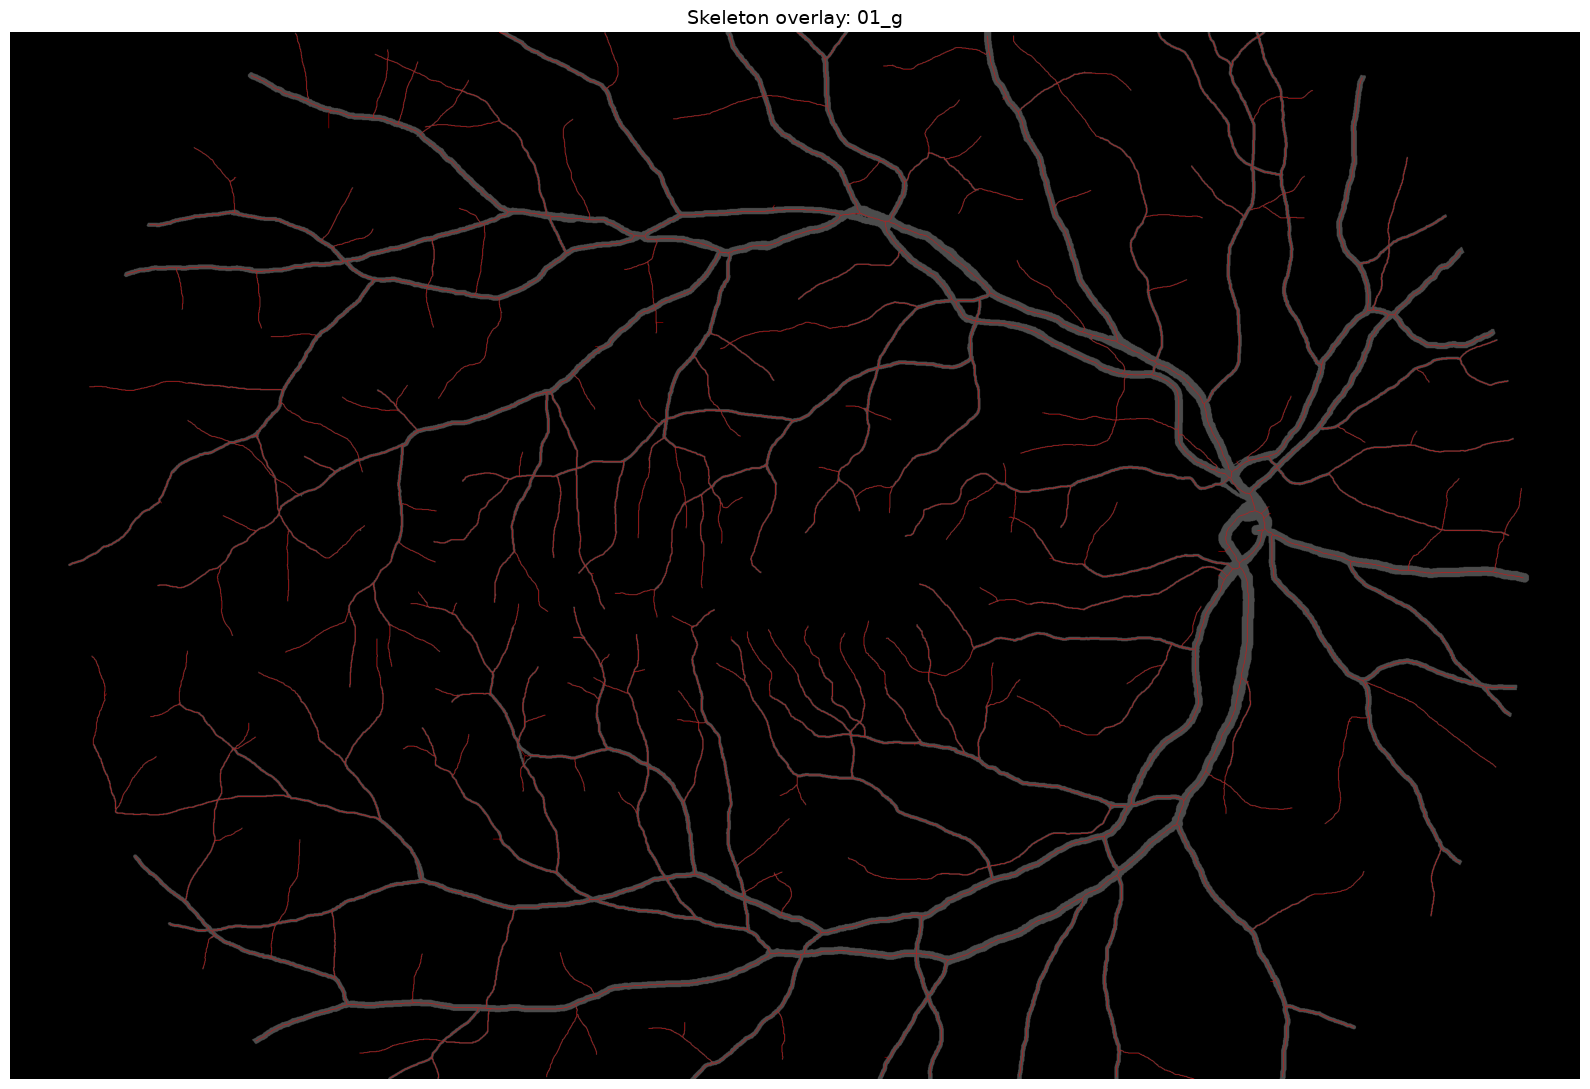

In [3]:
# Visual inspection: skeleton overlay for first sample
_, seg, mask, info = dataset.load_sample(1)
binary = preprocess_segmentation(seg, mask, min_size=50)
ex = analyze_segmentation_mask(binary, config)

overlay = np.dstack([binary * 0.3] * 3)
overlay[ex.skeleton > 0] = [1, 0, 0]

fig, ax = plt.subplots(figsize=(16, 12))
ax.imshow(overlay)
ax.set_title(f"Skeleton overlay: {info['name']}", fontsize=14)
ax.axis("off")
plt.tight_layout()
plt.show()

### Clean and Scale Features

In [4]:
# Remove zero-variance features (unsupervised, safe outside CV)
vt = VarianceThreshold(threshold=0.0)
X = vt.fit_transform(X)
df = df.loc[:, df.columns[vt.get_support()]]

# NOTE: SelectKBest is intentionally *not* applied here any more - it's
# supervised (uses y), so fitting it globally before cross-validation let
# every CV "test" fold's labels influence which K features were kept before
# CV ever started. It now lives inside each model's own Pipeline below,
# fit fresh on each fold's training data only.
K = 10

f"{df.shape[1]} features remain after variance filtering"

'27 features remain after variance filtering'

In [5]:
# Scaling now happens inside each model's own Pipeline (see below), not
# globally here - a global StandardScaler().fit_transform(X) would let
# each fold's held-out samples influence the normalization applied to
# that fold's own training data.
df.head()

,num_nodes,num_edges,num_endpoints,num_bifurcations,total_length,mean_length,std_length,max_length,min_length,mean_tortuosity,...,vessel_area,vessel_area_fraction,mean_radius,std_radius,max_radius,mean_diameter,std_diameter,max_diameter,mean_segment_volume,mean_surface_area
image,,,,,,,,,,,,,,,,,,,,,
01_dr,328.0,361.0,132.0,196.0,55548.502202,153.873967,152.950641,913.837662,1.0,1.081076,...,410479.0,0.054167,4.091208,3.664855,44.384682,8.182415,7.329709,88.769364,14699.638913,3982.265924
01_g,606.0,677.0,232.0,374.0,77236.595985,114.086552,100.894803,576.132034,1.0,1.080851,...,543661.0,0.071346,3.868883,2.862744,25.179357,7.737767,5.725488,50.358713,8365.250097,2788.412403
01_h,694.0,726.0,316.0,378.0,86925.369932,119.731915,93.955897,556.269119,1.0,1.085998,...,834033.0,0.109688,5.195090,3.321156,23.086793,10.390180,6.642312,46.173586,14455.922231,3932.049218
02_dr,506.0,544.0,217.0,289.0,71594.998513,131.608453,122.309353,789.901587,1.0,1.088649,...,519185.0,0.069002,3.955678,3.086397,31.780497,7.911356,6.172795,63.560994,10457.339676,3288.787836
02_g,746.0,814.0,305.0,441.0,84690.109689,104.041904,88.074025,569.274170,1.0,1.083294,...,606554.0,0.079600,3.915051,2.877691,18.000000,7.830102,5.755383,36.000000,7779.326947,2573.592161


### Random Forest

In [6]:
rf = RandomForestClassifier(random_state=42)

params = {
    "n_estimators": [100, 300, 500],
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt", "log2"],
    "criterion": ["gini", "entropy"],
}
params = {f"clf__{k}": v for k, v in params.items()}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_pipe = Pipeline([
    ("select", SelectKBest(f_classif, k=K)),
    ("scale", StandardScaler()),
    ("clf", rf),
])

rf_grid = GridSearchCV(
    estimator=rf_pipe,
    param_grid=params,
    scoring="accuracy",
    cv=cv,
    n_jobs=-1,
    return_train_score=True,
)

rf_grid.fit(X, y)

print(f"Best score: {rf_grid.best_score_}")
print(f"Best params: {rf_grid.best_params_}")

best_rf_model = rf_grid.best_estimator_

/home/woody/iwbn/iwbn007h/maskel_project/maskel-evaluations/.venv/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [8] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/home/woody/iwbn/iwbn007h/maskel_project/maskel-evaluations/.venv/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/home/woody/iwbn/iwbn007h/maskel_project/maskel-evaluations/.venv/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [8] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/home/woody/iwbn/iwbn007h/maskel_project/maskel-evaluations/.venv/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/home/woody/iwbn

Best score: 0.8222222222222222
Best params: {'clf__criterion': 'entropy', 'clf__max_depth': None, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 2, 'clf__min_samples_split': 2, 'clf__n_estimators': 300}


In [7]:
selected_mask = best_rf_model.named_steps["select"].get_support()
selected_features = df.columns[selected_mask]

importances = (
    pd.DataFrame(
        {
            "feature": selected_features,
            "importance": best_rf_model.named_steps["clf"].feature_importances_,
        }
    )
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)
importances

,feature,importance
0,mean_diameter,0.207428
1,mean_radius,0.205982
2,mean_tortuosity,0.117279
3,vessel_area,0.096114
4,vessel_area_fraction,0.094635
5,mean_segment_volume,0.089037
6,mean_surface_area,0.069837
7,std_diameter,0.044039
8,std_radius,0.041668
9,max_degree,0.033980


### Support Vector Machine

In [8]:
svm = SVC()

svm_params = {
    "C": [0.1, 1, 10, 100],
    "kernel": ["linear", "rbf", "poly"],
    "gamma": ["scale", "auto"],
    "degree": [2, 3],
}
svm_params = {f"clf__{k}": v for k, v in svm_params.items()}

svm_pipe = Pipeline([
    ("select", SelectKBest(f_classif, k=K)),
    ("scale", StandardScaler()),
    ("clf", svm),
])

svm_grid = GridSearchCV(
    estimator=svm_pipe,
    param_grid=svm_params,
    scoring="accuracy",
    cv=cv,
    n_jobs=-1,
    return_train_score=True,
)

svm_grid.fit(X, y)

print(f"Best score: {svm_grid.best_score_}")
print(f"Best params: {svm_grid.best_params_}")

best_svm_model = svm_grid.best_estimator_

/home/woody/iwbn/iwbn007h/maskel_project/maskel-evaluations/.venv/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [8] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/home/woody/iwbn/iwbn007h/maskel_project/maskel-evaluations/.venv/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/home/woody/iwbn/iwbn007h/maskel_project/maskel-evaluations/.venv/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [8] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/home/woody/iwbn/iwbn007h/maskel_project/maskel-evaluations/.venv/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/home/woody/iwbn

Best score: 0.8222222222222222
Best params: {'clf__C': 0.1, 'clf__degree': 2, 'clf__gamma': 'scale', 'clf__kernel': 'rbf'}


/home/woody/iwbn/iwbn007h/maskel_project/maskel-evaluations/.venv/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/home/woody/iwbn/iwbn007h/maskel_project/maskel-evaluations/.venv/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [8] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/home/woody/iwbn/iwbn007h/maskel_project/maskel-evaluations/.venv/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/home/woody/iwbn/iwbn007h/maskel_project/maskel-evaluations/.venv/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [8] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/home/woody/iwbn

### Logistic Regression

In [9]:
logreg = LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")

logreg_params = {
    "C": [0.01, 0.1, 1, 10, 100],
    "solver": ["lbfgs", "newton-cg", "sag", "saga"],
}
logreg_params = {f"clf__{k}": v for k, v in logreg_params.items()}

logreg_pipe = Pipeline([
    ("select", SelectKBest(f_classif, k=K)),
    ("scale", StandardScaler()),
    ("clf", logreg),
])

logreg_grid = GridSearchCV(
    estimator=logreg_pipe,
    param_grid=logreg_params,
    scoring="accuracy",
    cv=cv,
    n_jobs=-1,
    return_train_score=True,
)

logreg_grid.fit(X, y)

print(f"Best score: {logreg_grid.best_score_}")
print(f"Best params: {logreg_grid.best_params_}")

best_logreg_model = logreg_grid.best_estimator_

/home/woody/iwbn/iwbn007h/maskel_project/maskel-evaluations/.venv/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [8] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/home/woody/iwbn/iwbn007h/maskel_project/maskel-evaluations/.venv/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/home/woody/iwbn/iwbn007h/maskel_project/maskel-evaluations/.venv/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [8] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/home/woody/iwbn/iwbn007h/maskel_project/maskel-evaluations/.venv/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/home/woody/iwbn

Best score: 0.8666666666666668
Best params: {'clf__C': 0.01, 'clf__solver': 'lbfgs'}


/home/woody/iwbn/iwbn007h/maskel_project/maskel-evaluations/.venv/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [8] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/home/woody/iwbn/iwbn007h/maskel_project/maskel-evaluations/.venv/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/home/woody/iwbn/iwbn007h/maskel_project/maskel-evaluations/.venv/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [8] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/home/woody/iwbn/iwbn007h/maskel_project/maskel-evaluations/.venv/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/home/woody/iwbn

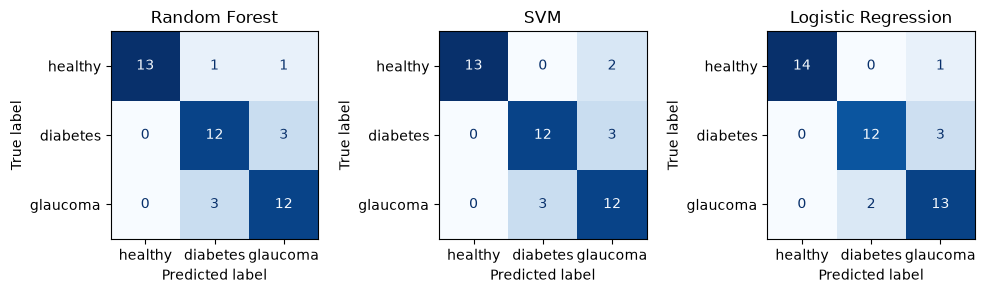

In [10]:
models = [
    ("Random Forest", best_rf_model),
    ("SVM", best_svm_model),
    ("Logistic Regression", best_logreg_model),
]

labels = [name for name, _ in sorted(phenotype_encode.items(), key=lambda kv: kv[1])]

fig, axes = plt.subplots(1, 3, figsize=(10, 3))
for ax, (name, model) in zip(axes, models):
    y_pred = cross_val_predict(model, X, y, cv=cv, n_jobs=-1)
    cm = confusion_matrix(y, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.savefig("./figures/individual_confusion_matrices.svg")
plt.show()

### Voting and Stacking Ensembles

/home/woody/iwbn/iwbn007h/maskel_project/maskel-evaluations/.venv/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [8] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/home/woody/iwbn/iwbn007h/maskel_project/maskel-evaluations/.venv/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/home/woody/iwbn/iwbn007h/maskel_project/maskel-evaluations/.venv/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [8] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/home/woody/iwbn/iwbn007h/maskel_project/maskel-evaluations/.venv/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/home/woody/iwbn

Voting Classifier accuracy: 0.822


/home/woody/iwbn/iwbn007h/maskel_project/maskel-evaluations/.venv/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [8] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/home/woody/iwbn/iwbn007h/maskel_project/maskel-evaluations/.venv/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/home/woody/iwbn/iwbn007h/maskel_project/maskel-evaluations/.venv/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [8] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/home/woody/iwbn/iwbn007h/maskel_project/maskel-evaluations/.venv/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/home/woody/iwbn

Stacking Classifier accuracy: 0.822


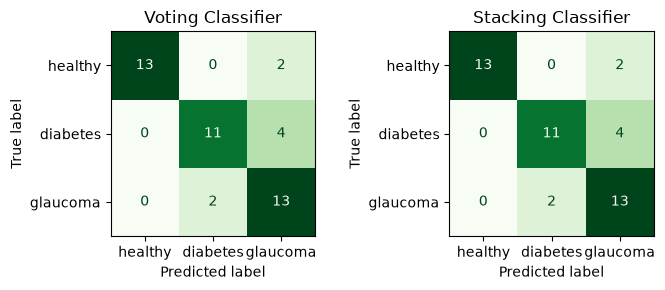

In [11]:
rf = Pipeline([
    ("select", SelectKBest(f_classif, k=K)),
    ("scale", StandardScaler()),
    ("clf", RandomForestClassifier(n_estimators=200, random_state=0)),
])
svm = Pipeline([
    ("select", SelectKBest(f_classif, k=K)),
    ("scale", StandardScaler()),
    ("clf", SVC(probability=True, kernel="rbf", C=1.0, random_state=0)),
])
log = Pipeline([
    ("select", SelectKBest(f_classif, k=K)),
    ("scale", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, solver="lbfgs", random_state=0)),
])

ensemble_models = [
    (
        "Voting Classifier",
        VotingClassifier(
            estimators=[("rf", rf), ("svm", svm), ("log", log)],
            voting="hard",
            n_jobs=-1,
        ),
    ),
    (
        "Stacking Classifier",
        StackingClassifier(
            estimators=[("rf", rf), ("svm", svm), ("log", log)],
            final_estimator=LogisticRegression(max_iter=1000, solver="lbfgs"),
            cv=5,
            passthrough=False,
        ),
    ),
]

fig, axes = plt.subplots(1, 2, figsize=(7, 3))
for ax, (name, model) in zip(axes, ensemble_models):
    y_pred = cross_val_predict(model, X, y, cv=cv, n_jobs=-1)
    cm = confusion_matrix(y, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(ax=ax, cmap="Greens", colorbar=False)
    ax.set_title(name)
    print(f"{name} accuracy: {(y_pred == y).mean():.3f}")

plt.tight_layout()
plt.savefig("./figures/ensemble_confusion_matrices.svg")
plt.show()

### Comparison

/home/woody/iwbn/iwbn007h/maskel_project/maskel-evaluations/.venv/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [8] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/home/woody/iwbn/iwbn007h/maskel_project/maskel-evaluations/.venv/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/home/woody/iwbn/iwbn007h/maskel_project/maskel-evaluations/.venv/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [8] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/home/woody/iwbn/iwbn007h/maskel_project/maskel-evaluations/.venv/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/home/woody/iwbn

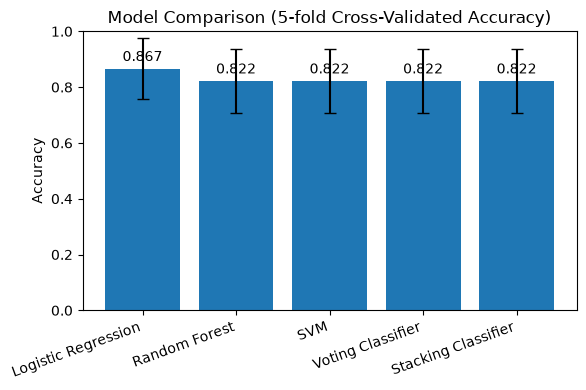

,Model,Mean Accuracy,Std
0,Logistic Regression,0.866667,0.108866
1,Random Forest,0.822222,0.113312
2,SVM,0.822222,0.113312
3,Voting Classifier,0.822222,0.113312
4,Stacking Classifier,0.822222,0.113312


In [12]:
comparison_models = [
    ("Random Forest", best_rf_model),
    ("SVM", best_svm_model),
    ("Logistic Regression", best_logreg_model),
    *ensemble_models,
]

scores = []
for name, model in comparison_models:
    cv_scores = cross_val_score(model, X, y, cv=cv, scoring="accuracy", n_jobs=-1)
    scores.append(
        {
            "Model": name,
            "Mean Accuracy": cv_scores.mean(),
            "Std": cv_scores.std(),
        }
    )

scores_df = (
    pd.DataFrame(scores)
    .sort_values("Mean Accuracy", ascending=False)
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(
    scores_df["Model"],
    scores_df["Mean Accuracy"],
    yerr=scores_df["Std"],
    capsize=4,
    # color=["#66c2a5", "#fc8d62", "#8da0cb", "#e78ac3", "#a6d854", "#ffd92f"]
)
ax.set_title("Model Comparison (5-fold Cross-Validated Accuracy)")
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1)
plt.xticks(rotation=20, ha="right")

for i, v in enumerate(scores_df["Mean Accuracy"]):
    ax.text(i, v + 0.015, f"{v:.3f}", ha="center", va="bottom")

plt.tight_layout()
plt.savefig("./figures/final_model_comparison.svg")
plt.show()

scores_df

### Effect of Number of Features on SVM Performance

In [13]:
df_full = pd.read_csv("full_features.csv", index_col=0)
y_full = sample_meta["phenotype"].map(phenotype_encode).values

vt = VarianceThreshold(threshold=0.0)
X_full = vt.fit_transform(df_full.values)
df_full = df_full.loc[:, df_full.columns[vt.get_support()]]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

k_values = [2, 4, 6, 8, 10, 12, 14, 16, 20, 24, 28]
svm_grid_base = {
    "C": [0.1, 1, 10, 100],
    "kernel": ["linear", "rbf", "poly"],
    "gamma": ["scale", "auto"],
    "degree": [2, 3],
}

results = []
for k in k_values:
    if k > df_full.shape[1]:
        continue
    pipe = Pipeline([
        ("select", SelectKBest(f_classif, k=k)),
        ("scale", StandardScaler()),
        ("clf", SVC()),
    ])
    param_grid = {f"clf__{key}": val for key, val in svm_grid_base.items()}

    grid = GridSearchCV(
        pipe,
        param_grid,
        scoring="accuracy",
        cv=cv,
        n_jobs=-1,
        return_train_score=True,
    )
    grid.fit(X_full, y_full)

    results.append(
        {
            "k": k,
            "best_score": grid.best_score_,
            "best_params": grid.best_params_,
            "train_score": grid.cv_results_["mean_train_score"][grid.best_index_],
        }
    )
    print(
        f"k={k:2d}  best_score={grid.best_score_:.4f}  train_score={results[-1]['train_score']:.4f}"
    )

results_df = pd.DataFrame(results)
results_df

/home/woody/iwbn/iwbn007h/maskel_project/maskel-evaluations/.venv/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [8] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/home/woody/iwbn/iwbn007h/maskel_project/maskel-evaluations/.venv/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/home/woody/iwbn/iwbn007h/maskel_project/maskel-evaluations/.venv/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [8] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/home/woody/iwbn/iwbn007h/maskel_project/maskel-evaluations/.venv/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/home/woody/iwbn

k= 2  best_score=0.8000  train_score=0.7889


/home/woody/iwbn/iwbn007h/maskel_project/maskel-evaluations/.venv/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [8] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/home/woody/iwbn/iwbn007h/maskel_project/maskel-evaluations/.venv/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/home/woody/iwbn/iwbn007h/maskel_project/maskel-evaluations/.venv/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [8] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/home/woody/iwbn/iwbn007h/maskel_project/maskel-evaluations/.venv/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/home/woody/iwbn

k= 4  best_score=0.8000  train_score=0.8111


/home/woody/iwbn/iwbn007h/maskel_project/maskel-evaluations/.venv/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [8] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/home/woody/iwbn/iwbn007h/maskel_project/maskel-evaluations/.venv/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/home/woody/iwbn/iwbn007h/maskel_project/maskel-evaluations/.venv/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [8] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/home/woody/iwbn/iwbn007h/maskel_project/maskel-evaluations/.venv/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/home/woody/iwbn

...

k=20  best_score=0.8667  train_score=0.9667


/home/woody/iwbn/iwbn007h/maskel_project/maskel-evaluations/.venv/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [8] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/home/woody/iwbn/iwbn007h/maskel_project/maskel-evaluations/.venv/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/home/woody/iwbn/iwbn007h/maskel_project/maskel-evaluations/.venv/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [8] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/home/woody/iwbn/iwbn007h/maskel_project/maskel-evaluations/.venv/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/home/woody/iwbn

k=24  best_score=0.8667  train_score=0.9611


/home/woody/iwbn/iwbn007h/maskel_project/maskel-evaluations/.venv/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [8] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/home/woody/iwbn/iwbn007h/maskel_project/maskel-evaluations/.venv/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/home/woody/iwbn/iwbn007h/maskel_project/maskel-evaluations/.venv/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [8] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/home/woody/iwbn/iwbn007h/maskel_project/maskel-evaluations/.venv/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/home/woody/iwbn

,k,best_score,best_params,train_score
0,2,0.800000,"{'clf__C': 0.1, 'clf__degree': 2, 'clf__gamma'...",0.788889
1,4,0.800000,"{'clf__C': 1, 'clf__degree': 2, 'clf__gamma': ...",0.811111
2,6,0.844444,"{'clf__C': 100, 'clf__degree': 2, 'clf__gamma'...",0.933333
3,8,0.800000,"{'clf__C': 1, 'clf__degree': 2, 'clf__gamma': ...",0.855556
4,10,0.822222,"{'clf__C': 0.1, 'clf__degree': 2, 'clf__gamma'...",0.916667
5,12,0.844444,"{'clf__C': 0.1, 'clf__degree': 2, 'clf__gamma'...",0.933333
6,14,0.844444,"{'clf__C': 0.1, 'clf__degree': 2, 'clf__gamma'...",0.944444
7,16,0.888889,"{'clf__C': 0.1, 'clf__degree': 2, 'clf__gamma'...",0.961111
8,20,0.866667,"{'clf__C': 0.1, 'clf__degree': 2, 'clf__gamma'...",0.966667
9,24,0.866667,"{'clf__C': 0.1, 'clf__degree': 2, 'clf__gamma'...",0.961111


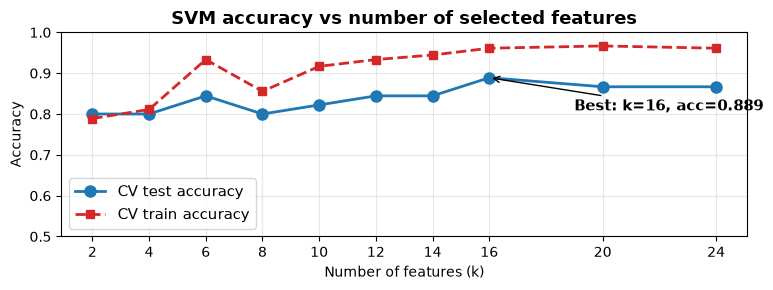

In [14]:
fig, ax = plt.subplots(figsize=(8, 3))

ax.plot(
    results_df["k"],
    results_df["best_score"],
    "o-",
    color="#1f77b4",
    linewidth=2,
    markersize=8,
    label="CV test accuracy",
)
ax.plot(
    results_df["k"],
    results_df["train_score"],
    "s--",
    color="#d62728",
    linewidth=2,
    markersize=6,
    label="CV train accuracy",
)

ax.set_xlabel("Number of features (k)")
ax.set_ylabel("Accuracy")
ax.set_title(
    "SVM accuracy vs number of selected features", fontsize=13, fontweight="bold"
)
ax.set_xticks(results_df["k"])
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
ax.set_ylim(0.5, 1.0)

best_idx = results_df["best_score"].idxmax()
best_k = results_df.loc[best_idx, "k"]
best_score = results_df.loc[best_idx, "best_score"]
ax.annotate(
    f"Best: k={best_k}, acc={best_score:.3f}",
    xy=(best_k, best_score),
    xytext=(best_k + 3, best_score - 0.08),
    arrowprops={"arrowstyle": "->", "color": "black"},
    fontsize=11,
    fontweight="bold",
)

plt.tight_layout()
plt.savefig("./figures/svm_k_sweep.svg", bbox_inches="tight")
plt.show()